# 09 - Image : Modélisation Baseline

## Objectif de ce notebook
Établir une **référence de performance** pour la **classification par images** en entraînant plusieurs modèles baselines sur les features extraites d'images produits (ResNet50 pré-entraîné). Prédiction du `prdtypecode` en 27 classes.

**Prérequis** : Exécuter les notebooks 07 et 08 (exploration et traitement). Images nettoyées dans `data/processed/image_clean/`.

**Livrable** : Modèle baseline de référence, extracteur de features et label encoder sauvegardés dans `models/`.

---

## Plan
1. Chargement des données images (produits avec image)
2. Extraction des features (ResNet50 backbone, 2048-dim)
3. Préparation des labels et division train/validation
4. Entraînement des modèles baselines (LogReg, SVM, RF)
5. Évaluation et comparaison des modèles
6. Visualisations, matrice de confusion
7. Sauvegarde des modèles pour le notebook 10

In [1]:
# Import des bibliothèques nécessaires
import os
os.environ['OMP_NUM_THREADS'] = str(os.cpu_count() or 4)

import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import pickle
import warnings
warnings.filterwarnings('ignore')

# Reproductibilité
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

sys.path.append(str(Path('../').resolve()))

from src.image import load_image_classification_data, ImageFeatureExtractor
from src.image.data_loader import create_train_val_split
from src.modeling import BaselineModels
from src.evaluation import evaluate_model, print_classification_report, plot_confusion_matrix

from sklearn.preprocessing import LabelEncoder

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ Bibliothèques importées avec succès")

✅ Bibliothèques importées avec succès


## 1. Chargement des Données Images

Chargement des produits **train** ayant une image associée (donc avec label).

🔄 Chargement des données images...
✅ Dataset chargé depuis image_dataset_processed.csv
⚠️ CSV sans labels, reconstruction depuis image_clean + Y_train...
✅ 44,969 produits avec image chargés
   - Colonne images : image_path
   - Nombre de classes : 27
   - Distribution (top 5) :
prdtypecode
2583    5348
1560    2748
2060    2700
1300    2673
2522    2603
Name: count, dtype: int64

📊 Distribution des classes (après nettoyage) :
prdtypecode
10      1593
40      1334
50       907
60       427
1140    1413
1160    2026
1180     408
1280    2549
1281    1075
1300    2673
1301     401
1302    1334
1320    1799
1560    2748
1920    2336
1940     394
2060    2700
2220     436
2280    2566
2403    2517
2462     761
2522    2603
2582    1344
2583    5348
2585    1340
2705    1470
2905     467

📊 Distribution des classes (24 classes, superclass) :
prdtypecode_superclass
40      1334
50       907
60       427
1140    1413
1160    2026
1180     408
1280    2549
1281    1075
1300    2673
1301     40

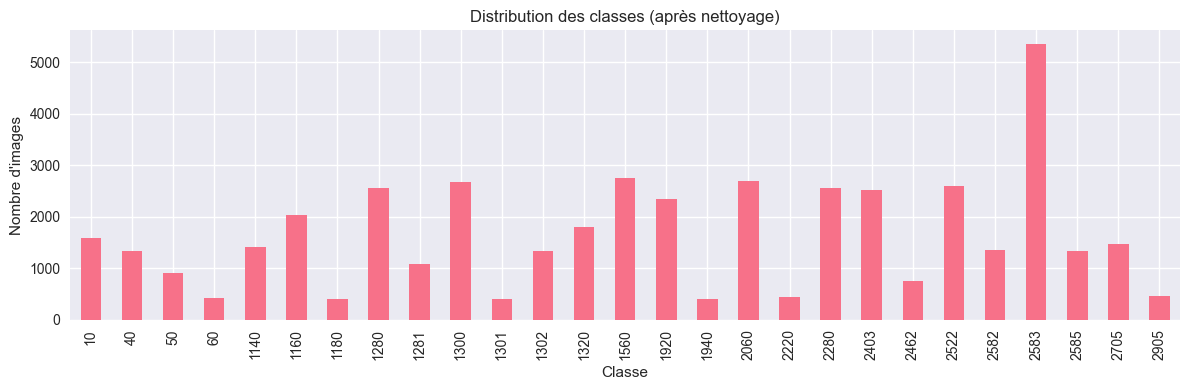

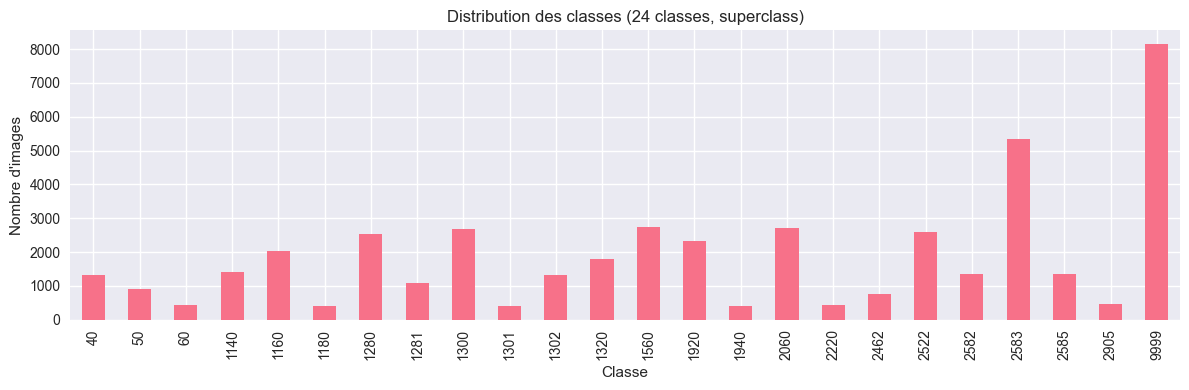

In [2]:
ROOT = Path('../').resolve()
DATA_BRUT = ROOT / 'data brut'
IMAGE_CLEAN_DIR = ROOT / 'data' / 'processed' / 'image_clean'
DATASET_CSV = ROOT / 'data' / 'processed' / 'image_dataset_processed.csv'
MODELS_DIR = ROOT / 'models'
MODELS_DIR.mkdir(exist_ok=True)

print("🔄 Chargement des données images...")
if DATASET_CSV.exists():
    image_df = pd.read_csv(DATASET_CSV)
    print(f"✅ Dataset chargé depuis {DATASET_CSV.name}")
else:
    image_df = load_image_classification_data(DATA_BRUT, IMAGE_CLEAN_DIR, root=ROOT)
    print("✅ Dataset construit depuis image_clean")

# Si le CSV ne contient pas de labels (cas test/brut), on reconstruit depuis le train
if 'prdtypecode' not in image_df.columns or image_df['prdtypecode'].isna().all():
    print("⚠️ CSV sans labels, reconstruction depuis image_clean + Y_train...")
    image_df = load_image_classification_data(DATA_BRUT, IMAGE_CLEAN_DIR, root=ROOT)

# Choix du chemin d'image à utiliser
if 'image_path_clean' in image_df.columns and image_df['image_path_clean'].notna().any():
    image_path_col = 'image_path_clean'
else:
    image_path_col = 'image_path'

# Vérification labels
if 'prdtypecode' not in image_df.columns or image_df['prdtypecode'].isna().all() or len(image_df) == 0:
    raise RuntimeError("Aucun label disponible. Vérifie que tu utilises des images train nettoyées.")

print(f"✅ {len(image_df):,} produits avec image chargés")
print(f"   - Colonne images : {image_path_col}")
print(f"   - Nombre de classes : {image_df['prdtypecode'].nunique()}")
print(f"   - Distribution (top 5) :")
print(image_df['prdtypecode'].value_counts().head())

# Distribution complète après nettoyage (27 classes)
class_counts = image_df['prdtypecode'].value_counts().sort_index()
print("\n📊 Distribution des classes (après nettoyage) :")
print(class_counts.to_string())

plt.figure(figsize=(12, 4))
class_counts.plot(kind='bar')
plt.title('Distribution des classes (après nettoyage)')
plt.xlabel('Classe')
plt.ylabel('Nombre d\'images')
plt.tight_layout()

## 2. Extraction des Features (ResNet50)

Extraction des features 2048-dim à partir du backbone ResNet50 pré-entraîné ImageNet. **Option** : sauvegarde/cache des features pour éviter de ré-extraire à chaque exécution.

In [3]:
FEATURES_CACHE = MODELS_DIR / 'image_features_cache.npz'

if FEATURES_CACHE.exists():
    print("🔄 Chargement des features depuis le cache...")
    cache = np.load(FEATURES_CACHE, allow_pickle=True)
    X_features = cache['X']
    y_labels = cache['y']
    indices = cache['indices']
    print(f"✅ Features chargées : {X_features.shape}")
else:
    print("🔄 Extraction des features (ResNet50)...")
    extractor = ImageFeatureExtractor(output_dim=2048)
    X_features = extractor.extract_from_paths(
        image_df[image_path_col].tolist(),
        base_dir=ROOT,
        batch_size=32,
        show_progress=True
    )
    y_labels = image_df['prdtypecode'].values
    indices = np.arange(len(image_df))
    np.savez(FEATURES_CACHE, X=X_features, y=y_labels, indices=indices)
    print(f"✅ Features extraites et sauvegardées : {X_features.shape}")

🔄 Chargement des features depuis le cache...
✅ Features chargées : (46857, 2048)


## 3. Préparation des Labels et Split Train/Validation

In [4]:
# Label encoder (27 classes)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_labels)

from sklearn.model_selection import train_test_split
indices = np.arange(len(y_labels))
train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

X_train_split = X_features[train_idx]
X_val_split = X_features[val_idx]
y_train = y_encoded[train_idx]
y_val = y_encoded[val_idx]

print(f"✅ Train : {X_train_split.shape[0]:,} | Validation : {X_val_split.shape[0]:,}")
print(f"   Features : {X_train_split.shape[1]} dimensions")
print(f"   Classes : {len(label_encoder.classes_)}")

✅ Train : 37,485 | Validation : 9,372
   Features : 2048 dimensions
✅ Scénarios : ['27 classes', '24 classes (superclass)']


In [5]:
with open(MODELS_DIR / 'label_encoder_image.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)
print("✅ Label encoder image sauvegardé (27 classes)")

✅ Label encoders image sauvegardés (27 et 24 classes)


## 4. Entraînement des Modèles Baselines

In [6]:
from sklearn.naive_bayes import GaussianNB
from sklearn.utils.class_weight import compute_class_weight

# --- Sans class weights ---
print("--- Baselines SANS class weights (27 classes) ---")
bm = BaselineModels(random_state=42)
bm.create_baseline_models()
bm.models['Naive Bayes'] = GaussianNB()
bm.train_all_models(X_train_split, y_train)

# --- Avec class weights (balanced) ---
print("\n--- Baselines AVEC class weights (27 classes) ---")
bm_w = BaselineModels(random_state=42)
bm_w.create_baseline_models()
bm_w.models['Logistic Regression'].set_params(class_weight='balanced')
bm_w.models['SVM (Linear)'].set_params(class_weight='balanced')
bm_w.models['Random Forest'].set_params(class_weight='balanced')
bm_w.models['Naive Bayes'] = GaussianNB()
bm_w.train_all_models(X_train_split, y_train)

print("\n✅ Tous les modèles entraînés (sans et avec class weights)")


--- Baselines SANS class weights - 27 classes ---
🔄 Entraînement de Naive Bayes...
✅ Naive Bayes entraîné avec succès
🔄 Entraînement de Logistic Regression...
✅ Logistic Regression entraîné avec succès
🔄 Entraînement de SVM (Linear)...
✅ SVM (Linear) entraîné avec succès
🔄 Entraînement de Random Forest...
✅ Random Forest entraîné avec succès
--- Baselines AVEC class weights - 27 classes ---
🔄 Entraînement de Naive Bayes...
✅ Naive Bayes entraîné avec succès
🔄 Entraînement de Logistic Regression...
✅ Logistic Regression entraîné avec succès
🔄 Entraînement de SVM (Linear)...
✅ SVM (Linear) entraîné avec succès
🔄 Entraînement de Random Forest...
✅ Random Forest entraîné avec succès

--- Baselines SANS class weights - 24 classes (superclass) ---
🔄 Entraînement de Naive Bayes...
✅ Naive Bayes entraîné avec succès
🔄 Entraînement de Logistic Regression...
✅ Logistic Regression entraîné avec succès
🔄 Entraînement de SVM (Linear)...
✅ SVM (Linear) entraîné avec succès
🔄 Entraînement de Random 

## 5. Évaluation et Comparaison

In [7]:
results_summary = []

# Sans class weights
for model_name in bm.trained_models.keys():
    y_pred = bm.predict(model_name, X_val_split)
    metrics = evaluate_model(y_val, y_pred)
    results_summary.append({
        'Model': model_name,
        'Weights': 'Non',
        'Accuracy': metrics['accuracy'],
        'F1_macro': metrics['f1_macro'],
        'F1_weighted': metrics['f1_weighted']
    })

# Avec class weights
for model_name in bm_w.trained_models.keys():
    y_pred_w = bm_w.predict(model_name, X_val_split)
    metrics_w = evaluate_model(y_val, y_pred_w)
    results_summary.append({
        'Model': model_name,
        'Weights': 'Oui',
        'Accuracy': metrics_w['accuracy'],
        'F1_macro': metrics_w['f1_macro'],
        'F1_weighted': metrics_w['f1_weighted']
    })

results_df = pd.DataFrame(results_summary).sort_values(['Model', 'Weights'], ascending=[True, True])

print(f"\n{'='*80}")
print(f"  Résultats Baselines Image (27 classes)")
print(f"{'='*80}")
for model_name in results_df['Model'].unique():
    m_df = results_df[results_df['Model'] == model_name]
    row_no = m_df[m_df['Weights'] == 'Non'].iloc[0] if len(m_df[m_df['Weights'] == 'Non']) else None
    row_yes = m_df[m_df['Weights'] == 'Oui'].iloc[0] if len(m_df[m_df['Weights'] == 'Oui']) else None
    f1_no = f"{row_no['F1_macro']:.4f}" if row_no is not None else "-"
    f1_yes = f"{row_yes['F1_macro']:.4f}" if row_yes is not None else "-"
    delta = ""
    if row_no is not None and row_yes is not None:
        d = row_yes['F1_macro'] - row_no['F1_macro']
        delta = f" ({d:+.4f})"
    print(f"  {model_name:<22} sans={f1_no}  avec={f1_yes}{delta}")

results_df.to_csv(MODELS_DIR / 'image_baseline_comparison.csv', index=False)
print(f"\n✅ Résultats sauvegardés dans models/image_baseline_comparison.csv")


  24 classes (superclass)
  Logistic Regression    sans=0.0434  avec=0.0354 (-0.0080)
  Naive Bayes            sans=0.0249  avec=0.0249 (+0.0000)
  Random Forest          sans=0.0172  avec=0.0416 (+0.0244)
  SVM (Linear)           sans=0.0388  avec=0.0313 (-0.0075)

  27 classes
  Logistic Regression    sans=0.0415  avec=0.0311 (-0.0104)
  Naive Bayes            sans=0.0238  avec=0.0238 (+0.0000)
  Random Forest          sans=0.0099  avec=0.0375 (+0.0276)
  SVM (Linear)           sans=0.0363  avec=0.0281 (-0.0081)

Resultats sauvegardes dans models/image_baseline_comparison.csv


## 6. Validation Croisée

Validation croisée pour obtenir une estimation plus robuste des performances.

In [8]:
from sklearn.naive_bayes import GaussianNB

cv_results = []

for weights_label, use_weights in [('Sans weights', False), ('Avec weights', True)]:
    cv_m = BaselineModels(random_state=SEED)
    cv_m.create_baseline_models()
    if use_weights:
        cv_m.models['Logistic Regression'].set_params(class_weight='balanced')
        cv_m.models['SVM (Linear)'].set_params(class_weight='balanced')
        cv_m.models['Random Forest'].set_params(class_weight='balanced')
    cv_m.models['Naive Bayes'] = GaussianNB()

    print(f"\nVALIDATION CROISÉE 5 folds - {weights_label}")
    for model_name in cv_m.models.keys():
        res = cv_m.cross_validate(model_name, X_features, y_encoded, cv=5, scoring='f1_macro')
        cv_results.append({
            'Model': model_name,
            'Weights': weights_label,
            'CV_F1_mean': res['mean'],
            'CV_F1_std': res['std']
        })

cv_df = pd.DataFrame(cv_results)

print(f"\n{'='*70}")
print(f"  CV 5 folds - 27 classes")
print(f"{'='*70}")
for model_name in cv_df['Model'].unique():
    m = cv_df[cv_df['Model'] == model_name]
    sans = m[m['Weights'] == 'Sans weights'].iloc[0]
    avec = m[m['Weights'] == 'Avec weights'].iloc[0]
    d = avec['CV_F1_mean'] - sans['CV_F1_mean']
    print(f"  {model_name:<22} sans={sans['CV_F1_mean']:.4f}  avec={avec['CV_F1_mean']:.4f}  ({d:+.4f})")


VALIDATION CROISEE 5 folds - Sans weights
  27 classes...
  24 classes (superclass)...

VALIDATION CROISEE 5 folds - Avec weights
  27 classes...


KeyboardInterrupt: 

## 6. Meilleur Modèle - Matrice de Confusion

In [ ]:
best_row = results_df.sort_values('F1_macro', ascending=False).iloc[0]
best_name = best_row['Model']
best_weights = best_row['Weights']

best_model = bm_w if best_weights == 'Oui' else bm
y_pred_best = best_model.predict(best_name, X_val_split)

class_names = [f"Classe {c}" for c in sorted(label_encoder.classes_)]
print(f"\nMATRICE DE CONFUSION - {best_name} (weights={best_weights})")
plot_confusion_matrix(y_val, y_pred_best, class_names=class_names, figsize=(16, 14), normalize=True)

## 7. Sauvegarde du Meilleur Modèle

In [ ]:
model_path = MODELS_DIR / f"image_{best_name.lower().replace(' ', '_')}_27_classes_baseline.pkl"
best_model.save_model(best_name, model_path)

results_df.to_csv(MODELS_DIR / 'image_baseline_comparison.csv', index=False)
print(f"✅ Meilleur modèle sauvegardé : {model_path.name}")
print("✅ Résultats sauvegardés dans models/image_baseline_comparison.csv")